<a href="https://colab.research.google.com/github/mad10116/BOOTCAMP-EDA-STUDY/blob/main/Copy_of_EDA_activity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### EDA Case Study

**Introduction**

This case study aims to give an idea of applying EDA in a real business scenario. In this case study, we will develop a basic understanding of risk analytics in banking and financial services and understand how data is used to minimize the risk of losing money while lending to customers.

**Business Understanding**

The loan providing companies find it hard to give loans to the people due to their insufficient or non-existent credit history. Because of that, some consumers use it as their advantage by becoming a defaulter. Suppose we work for a consumer finance company which specializes in lending various types of loans to urban customers. We will have to use EDA to analyze the patterns present in the data. This will ensure that the applicants capable of repaying the loan are not rejected.

When the company receives a loan application, the company has to decide for loan approval based on the applicant’s profile. Two types of risks are associated with the bank’s decision:

If the applicant is likely to repay the loan, then not approving the loan results in a loss of business to the company

If the applicant is not likely to repay the loan, i.e. he/she is likely to default, then approving the loan may lead to a financial loss for the company.

The data given below contains the information about the loan application at the time of applying for the loan. It contains two types of scenarios:

The client with payment difficulties: he/she had late payment more than X days on at least one of the first Y instalments of the loan in our sample,

All other cases: All other cases when the payment is paid on time.

When a client applies for a loan, there are four types of decisions that could be taken by the client/company):

Approved: The Company has approved loan Application

Cancelled: The client cancelled the application sometime during approval. Either the client changed her/his mind about the loan or in some cases due to a higher risk of the client he received worse pricing which he did not want.

Refused: The company had rejected the loan (because the client does not meet their requirements etc.).

Unused offer: Loan has been cancelled by the client but on different stages of the process.

In this case study, we will use EDA to understand how consumer attributes and loan attributes influence the tendency of default.

**Business Objectives**

This case study aims to identify patterns which indicate if a client has difficulty paying their installments which may be used for taking actions such as denying the loan, reducing the amount of loan, lending (to risky applicants) at a higher interest rate, etc. This will ensure that the consumers capable of repaying the loan are not rejected. Identification of such applicants using EDA is the aim of this case study.

In other words, the company wants to understand the driving factors (or driver variables) behind loan default, i.e. the variables which are strong indicators of default. The company can utilize this knowledge for its portfolio and risk assessment.

**Data Understanding**

This dataset has 3 files as explained below:

`application_data.csv` contains all the information of the client at the time of application.
The data is about whether a client has payment difficulties.

`previous_application.csv` contains information about the client’s previous loan data. It contains the data whether the previous application had been Approved, Cancelled, Refused or Unused offer.

`columns_description.xlsx` is data dictionary which describes the meaning of the variables.


I have given a link to the data files in a drive folder [here](https://drive.google.com/drive/folders/1YpPjU4Y12MPrMdWaNDa6rS2MNirh2FG3?usp=sharing).  I suggest unzipping them and putting them in your google drive, and link to them directly using colab and its "mount drive" functionality.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd
prevdata = pd.read_csv('/content/drive/MyDrive/previous_application.csv')
appdata=pd.read_csv('/content/drive/MyDrive/application_data.csv')

In [ ]:
for col in appdata.columns:
  appdata.groupby(col)['TARGET'].mean()

In [ ]:
appdata.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
numeric_cols = appdata.select_dtypes(include=['number']).columns

columns_to_process = [col for col in ['AMT_GOODS_PRICE','DAYS_BIRTH','DAYS_EMPLOYED','DAYS_REGISTRATION','DAYS_ID_PUBLISH','OWN_CAR_AGE','CNT_FAM_MEMBERS','REGION_RATING_CLIENT','REGION_RATING_CLIENT_W_CITY','HOUR_APPR_PROCESS_START','EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3','APARTMENTS_AVG','BASEMENTAREA_AVG','YEARS_BEGINEXPLUATATION_AVG','YEARS_BUILD_AVG','COMMONAREA_AVG','ELEVATORS_AVG','ENTRANCES_AVG','FLOORSMAX_AVG','FLOORSMIN_AVG','LANDAREA_AVG','LIVINGAPARTMENTS_AVG','LIVINGAREA_AVG','NONLIVINGAPARTMENTS_AVG','NONLIVINGAREA_AVG','APARTMENTS_MODE','BASEMENTAREA_MODE','YEARS_BEGINEXPLUATATION_MODE','YEARS_BUILD_MODE','COMMONAREA_MODE','ELEVATORS_MODE','ENTRANCES_MODE','FLOORSMAX_MODE','FLOORSMIN_MODE','LANDAREA_MODE','LIVINGAPARTMENTS_MODE','LIVINGAREA_MODE','NONLIVINGAPARTMENTS_MODE','NONLIVINGAREA_MODE','APARTMENTS_MEDI','BASEMENTAREA_MEDI','YEARS_BEGINEXPLUATATION_MEDI','YEARS_BUILD_MEDI','COMMONAREA_MEDI','ELEVATORS_MEDI','ENTRANCES_MEDI','FLOORSMAX_MEDI','FLOORSMIN_MEDI','LANDAREA_MEDI','LIVINGAPARTMENTS_MEDI','LIVINGAREA_MEDI','NONLIVINGAPARTMENTS_MEDI','NONLIVINGAREA_MEDI','FONDKAPREMONT_MODE','HOUSETYPE_MODE','TOTALAREA_MODE','WALLSMATERIAL_MODE','EMERGENCYSTATE_MODE','OBS_30_CNT_SOCIAL_CIRCLE','DEF_30_CNT_SOCIAL_CIRCLE','OBS_60_CNT_SOCIAL_CIRCLE','DEF_60_CNT_SOCIAL_CIRCLE','AMT_REQ_CREDIT_BUREAU_HOUR','AMT_REQ_CREDIT_BUREAU_DAY','AMT_REQ_CREDIT_BUREAU_WEEK','AMT_REQ_CREDIT_BUREAU_MON','AMT_REQ_CREDIT_BUREAU_QRT','AMT_REQ_CREDIT_BUREAU_YEAR'] if col in numeric_cols]

for col in columns_to_process:
  target_means = appdata.groupby('TARGET')[col].mean()
  print(target_means)

  if 0 in target_means.index and 1 in target_means.index:
    diff = (target_means.loc[1] - target_means.loc[0]) / appdata[col].mean()
    print('The DIFFERENCE IS', format((diff*100),'.2f')+"%")
  else:
    print(f"Cannot calculate difference for {col} as TARGET 0 or 1 is missing.")
  print()

TARGET
0    542736.795003
1    488972.412554
Name: AMT_GOODS_PRICE, dtype: float64
The DIFFERENCE IS -9.99%

TARGET
0   -16138.176397
1   -14884.828077
Name: DAYS_BIRTH, dtype: float64
The DIFFERENCE IS -7.82%

TARGET
0    65696.146123
1    42394.675448
Name: DAYS_EMPLOYED, dtype: float64
The DIFFERENCE IS -36.51%

TARGET
0   -5029.941065
1   -4487.127009
Name: DAYS_REGISTRATION, dtype: float64
The DIFFERENCE IS -10.89%

TARGET
0   -3017.219788
1   -2732.099617
Name: DAYS_ID_PUBLISH, dtype: float64
The DIFFERENCE IS -9.52%

TARGET
0    11.935540
1    13.668691
Name: OWN_CAR_AGE, dtype: float64
The DIFFERENCE IS 14.37%

TARGET
0    2.150154
1    2.181269
Name: CNT_FAM_MEMBERS, dtype: float64
The DIFFERENCE IS 1.45%

TARGET
0    2.043578
1    2.153635
Name: REGION_RATING_CLIENT, dtype: float64
The DIFFERENCE IS 5.36%

TARGET
0    2.022449
1    2.134824
Name: REGION_RATING_CLIENT_W_CITY, dtype: float64
The DIFFERENCE IS 5.53%

TARGET
0    12.086807
1    11.797100
Name: HOUR_APPR_PROCESS_S

In [ ]:
results_data = []

for col in columns_to_process:
    target_means = appdata.groupby('TARGET')[col].mean()
    mean0 = target_means.get(0, None) # Use .get() to handle cases where a target might be missing
    mean1 = target_means.get(1, None)

    difference = None
    if mean0 is not None and mean1 is not None:
        overall_mean = appdata[col].mean()
        if overall_mean != 0: # Avoid division by zero
            difference = (mean1 - mean0) / overall_mean * 100

    results_data.append({
        'column_name': col,
        'mean0': mean0,
        'mean1': mean1,
        'difference_percent': difference
    })

diff_df = pd.DataFrame(results_data).set_index('column_name')
display(diff_df.head())
display(diff_df.tail())

,mean0,mean1,difference_percent
column_name,,,
AMT_GOODS_PRICE,542736.795003,488972.412554,-9.986025
DAYS_BIRTH,-16138.176397,-14884.828077,-7.815356
DAYS_EMPLOYED,65696.146123,42394.675448,-36.514070
DAYS_REGISTRATION,-5029.941065,-4487.127009,-10.886501
DAYS_ID_PUBLISH,-3017.219788,-2732.099617,-9.522408


,mean0,mean1,difference_percent
column_name,,,
AMT_REQ_CREDIT_BUREAU_DAY,0.006914,0.008036,16.031896
AMT_REQ_CREDIT_BUREAU_WEEK,0.034315,0.034919,1.758035
AMT_REQ_CREDIT_BUREAU_MON,0.270697,0.227926,-15.995482
AMT_REQ_CREDIT_BUREAU_QRT,0.265939,0.259923,-2.265929
AMT_REQ_CREDIT_BUREAU_YEAR,1.889199,2.028783,7.346600


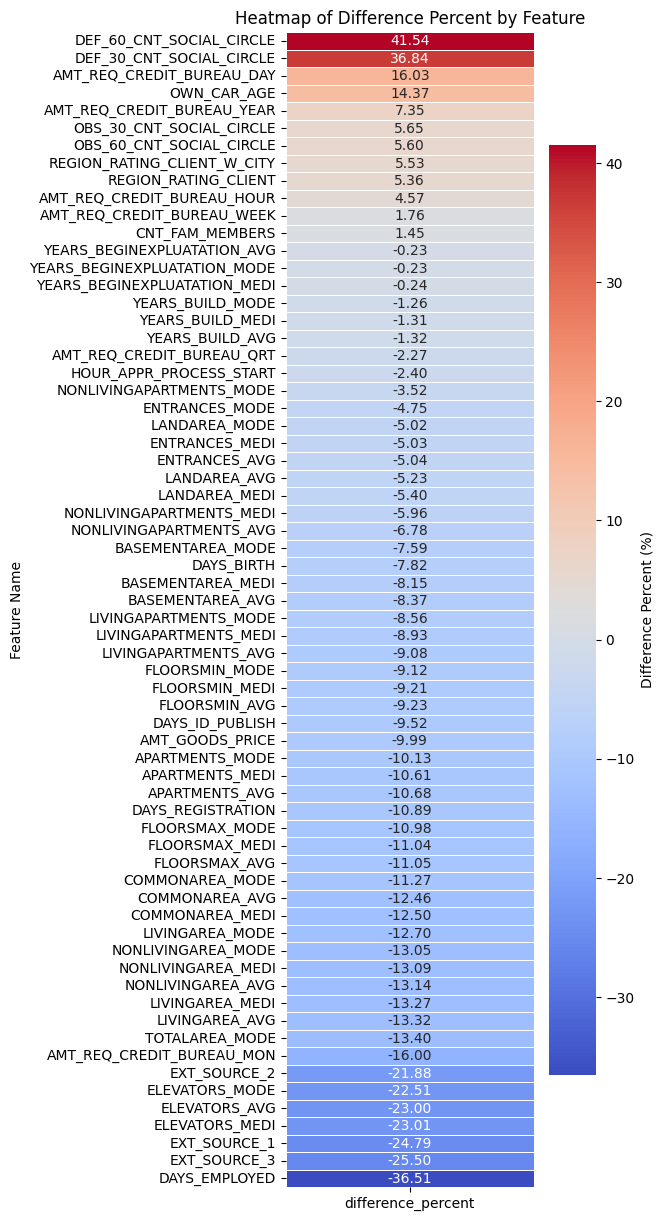

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the DataFrame by difference_percent to highlight the most impactful features
df_sorted = diff_df.sort_values(by='difference_percent', ascending=False)

# Create a heatmap of the difference_percent column
plt.figure(figsize=(4, 15)) # Adjust figure size as needed
sns.heatmap(df_sorted[['difference_percent']], annot=True, cmap='coolwarm', fmt=".2f",
            linewidths=.5, cbar_kws={'label': 'Difference Percent (%)'})
plt.title('Heatmap of Difference Percent by Feature')
plt.ylabel('Feature Name')
plt.show()

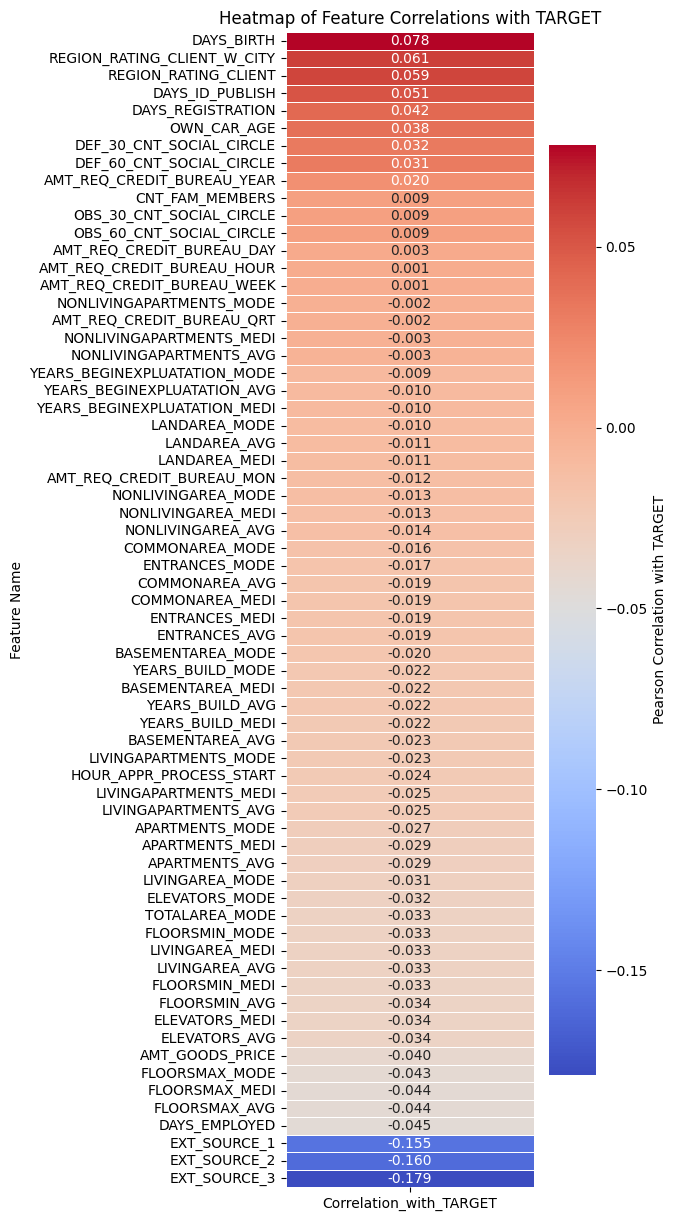

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the DataFrame by Correlation_with_TARGET to highlight the most impactful features
df_sorted_corr = correlation_df.sort_values(by='Correlation_with_TARGET', ascending=False)

# Create a heatmap of the Correlation_with_TARGET column
plt.figure(figsize=(4, 15)) # Adjust figure size as needed
sns.heatmap(df_sorted_corr[['Correlation_with_TARGET']], annot=True, cmap='coolwarm', fmt=".3f",
            linewidths=.5, cbar_kws={'label': 'Pearson Correlation with TARGET'})
plt.title('Heatmap of Feature Correlations with TARGET')
plt.ylabel('Feature Name')
plt.show()

In [ ]:
# Calculate the Pearson correlation coefficient for each variable with 'TARGET'
correlation_with_target = {}
for col in columns_to_process:
    correlation_with_target[col] = appdata[col].corr(appdata['TARGET'])

# Create a DataFrame from the correlation results for better readability
correlation_df = pd.DataFrame.from_dict(correlation_with_target, orient='index', columns=['Correlation_with_TARGET'])
correlation_df = correlation_df.sort_values(by='Correlation_with_TARGET', ascending=False)

display(correlation_df.head())
display(correlation_df.tail())

,Correlation_with_TARGET
DAYS_BIRTH,0.078239
REGION_RATING_CLIENT_W_CITY,0.060893
REGION_RATING_CLIENT,0.058899
DAYS_ID_PUBLISH,0.051457
DAYS_REGISTRATION,0.041975


,Correlation_with_TARGET
FLOORSMAX_AVG,-0.044003
DAYS_EMPLOYED,-0.044932
EXT_SOURCE_1,-0.155317
EXT_SOURCE_2,-0.160472
EXT_SOURCE_3,-0.178919
